# **Name:** Ahmed Huzaifa Malik
# **Ref - ID:** TC-INT-20260603-527

# **Task (1) - Customer Behavior Analytics & Churn Prediction Dashboard**

# **Dataset Loading**

In [1]:
# Importing required libraries for data exploration and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display the dataet
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No        

# **Data Exploration**

In [5]:
# Shape of the datset
print(df.shape)

(7043, 21)


In [6]:
# Basic info of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Class balance check
print(df['Churn'].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [8]:
# TotalCharges: coerce to numeric, blanks -> NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges:", df['TotalCharges'].isna().sum())

Missing TotalCharges: 11


In [9]:
# These 11 rows all have tenure == 0 (brand-new customers). Logical fill: 0, because a tenure-0 customer hasn't been billed a cumulative total yet.
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0.0

# Safety net for any other NaN:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [10]:
# Drop ID (not a feature)
df = df.drop(columns=['customerID'])

In [11]:
# Outlier check on numeric cols (don't blindly remove — these are legitimate)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df[num_cols].describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


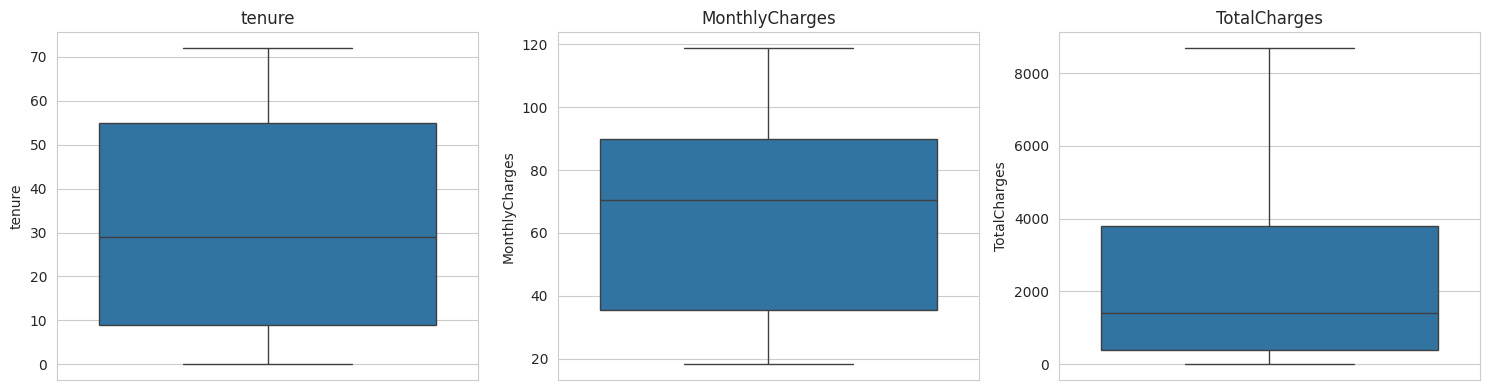

In [12]:
# Box plot for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax); ax.set_title(c)
plt.tight_layout(); plt.show()

# **Feature Engineering**

In [13]:
# Convert target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

In [14]:
# 1. Tenure buckets
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1,12,24,48,60,np.inf],
                            labels=['0-1yr','1-2yr','2-4yr','4-5yr','5yr+'])

In [15]:
# 2. Count of add-on services subscribed (proxy for engagement)
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

In [16]:
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

In [17]:
# 3. Charge ratio: avg monthly spend over lifetime vs current monthly
df['avg_monthly_total'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
df['charge_ratio'] = df['MonthlyCharges'] / df['avg_monthly_total'].replace(0, 1)

In [18]:
# 4. Auto-pay flag (electronic/auto methods correlate with retention)
df['auto_payment'] = df['PaymentMethod'].str.contains('automatic').astype(int)

In [19]:
# 5. Monthly contract flag (strongest churn driver in this dataset)
df['is_monthly'] = (df['Contract'] == 'Month-to-month').astype(int)

# **Data Visualization**

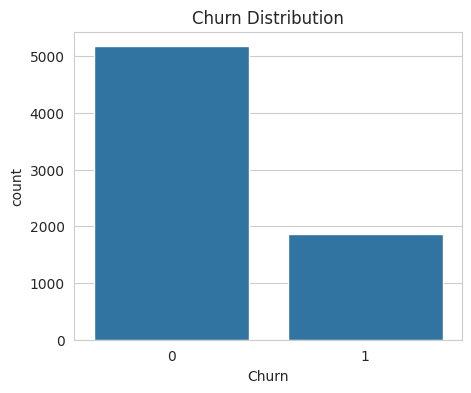

In [20]:
# Churn distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

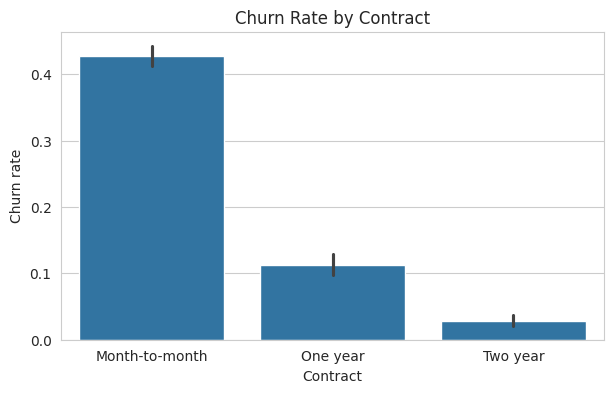

In [21]:
# Churn by contract type
plt.figure(figsize=(7,4))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title('Churn Rate by Contract')
plt.ylabel('Churn rate')
plt.show()

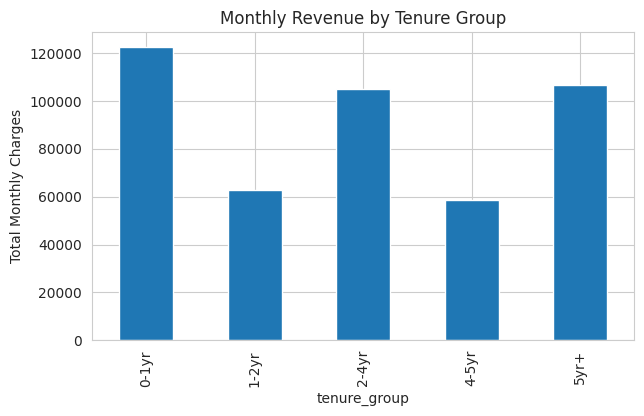

In [22]:
# "Revenue" by segment (snapshot, NOT a time trend — no dates in data)
plt.figure(figsize=(7,4))
df.groupby('tenure_group', observed=True)['MonthlyCharges'].sum().plot(kind='bar')
plt.title('Monthly Revenue by Tenure Group')
plt.ylabel('Total Monthly Charges')
plt.show()

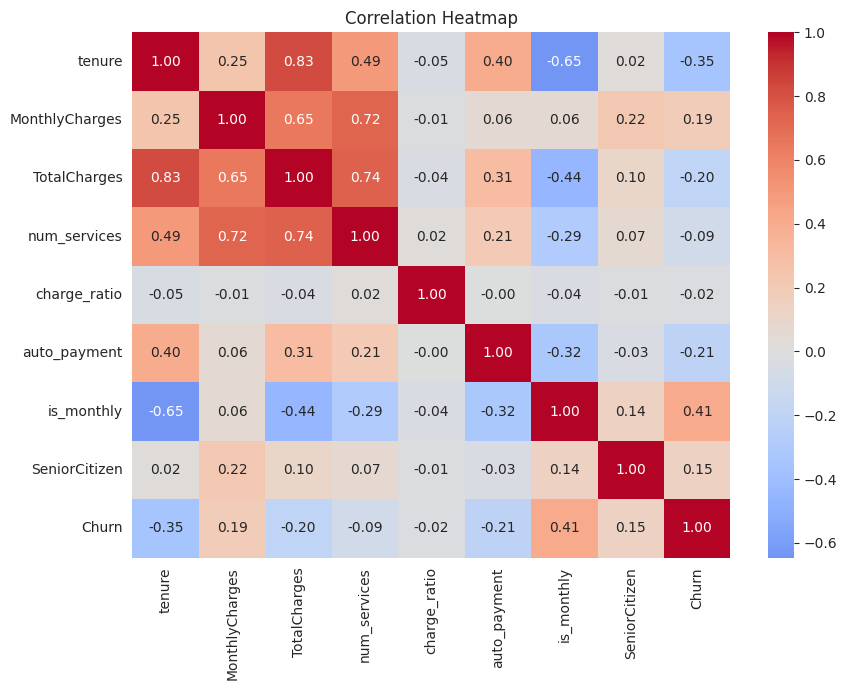

In [23]:
# Correlation heatmap (numeric + engineered)
plt.figure(figsize=(9,7))
corr_cols = ['tenure','MonthlyCharges','TotalCharges','num_services',
             'charge_ratio','auto_payment','is_monthly','SeniorCitizen','Churn']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# **Data Encoding and Spliting**

In [24]:
# Importing the required libraries for the process
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
# Dropping the categorical and generating dummies
model_df = df.drop(columns=['tenure_group'])
model_df = pd.get_dummies(model_df, drop_first=True)

In [26]:
# Splitting the data using train-test split
X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

In [27]:
# Initializing and stratifying the imbalanced target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# Scaling and transforming the splitted data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# **Model Training**

In [29]:
# Importing the required models and associated metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

In [30]:
# class_weight='balanced' because 26.5% churn, without it recall on churners is poor
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_s, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [31]:
# Training random forest
rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                            class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [32]:
# Training XGBoost
from xgboost import XGBClassifier
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                    scale_pos_weight=scale, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# **Model Evaluation**

In [33]:
# Evaluation function
def evaluate(name, model, Xte, yte):
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy_score(yte, pred):.3f}")
    print(f"Precision: {precision_score(yte, pred):.3f}")
    print(f"Recall   : {recall_score(yte, pred):.3f}")
    print(f"F1       : {f1_score(yte, pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(yte, proba):.3f}")
    print(classification_report(yte, pred))
    return proba

# Evaluationg models
p_lr = evaluate("Logistic Regression", logreg, X_test_s, y_test)
p_rf = evaluate("Random Forest", rf, X_test, y_test)
p_xgb = evaluate("XGBoost", xgb, X_test, y_test)


=== Logistic Regression ===
Accuracy : 0.740
Precision: 0.507
Recall   : 0.783
F1       : 0.616
ROC-AUC  : 0.841
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


=== Random Forest ===
Accuracy : 0.759
Precision: 0.532
Recall   : 0.767
F1       : 0.629
ROC-AUC  : 0.841
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409


=== XGBoost ===
Accuracy : 0.763
Precision: 0.540
Recall   : 0.714
F1       : 0.615
ROC-AUC  : 0.829
              precisio

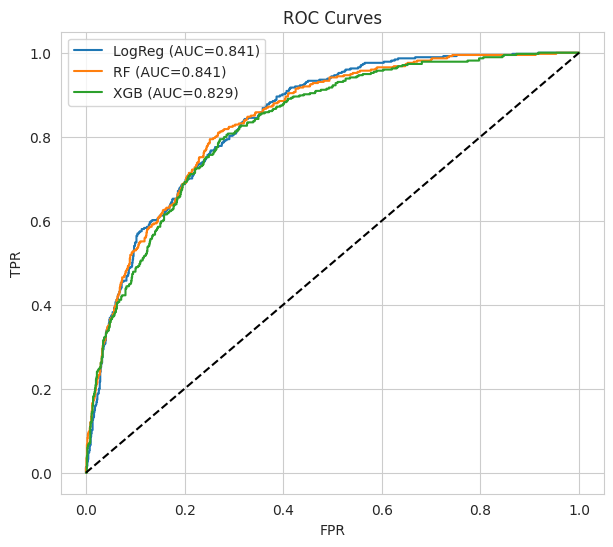

In [34]:
# ROC Curves
plt.figure(figsize=(7,6))
for name, p in [("LogReg", p_lr), ("RF", p_rf)] + ([("XGB", p_xgb)]):
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,p):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend()
plt.show()

# **Customer Segmentation**

In [35]:
# Value = total revenue contribution, use TotalCharges as lifetime value proxy.
df['value_segment'] = pd.qcut(df['TotalCharges'], q=3,
                              labels=['Low value','Medium value','High value'])
print(df.groupby('value_segment', observed=True).agg(
    customers=('Churn','size'),
    churn_rate=('Churn','mean'),
    avg_monthly=('MonthlyCharges','mean')))

               customers  churn_rate  avg_monthly
value_segment                                    
Low value           2348    0.393526    47.455771
Medium value        2347    0.237324    57.348402
High value          2348    0.165247    89.477747


# **Churn Probability and Risk Category**

In [36]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, logreg.predict(X_test_s)))

[[750 285]
 [ 81 293]]


In [37]:
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print("Pushes toward churn (largest positive):")
print(coefs.tail(10))
print("\nPushes against churn (largest negative):")
print(coefs.head(10))

Pushes toward churn (largest positive):
SeniorCitizen                     0.056489
num_services                      0.089702
PaymentMethod_Electronic check    0.117026
PaperlessBilling_Yes              0.164152
MultipleLines_Yes                 0.207632
StreamingTV_Yes                   0.259744
StreamingMovies_Yes               0.270568
is_monthly                        0.319366
TotalCharges                      0.492431
InternetService_Fiber optic       0.833426
dtype: float64

Pushes against churn (largest negative):
tenure                               -1.161442
MonthlyCharges                       -0.919399
charge_ratio                         -0.429345
Contract_Two year                    -0.337716
avg_monthly_total                    -0.178978
OnlineSecurity_Yes                   -0.131072
Dependents_Yes                       -0.103198
OnlineSecurity_No internet service   -0.101723
OnlineBackup_No internet service     -0.101723
StreamingTV_No internet service      -0.101723
dty

In [38]:
best_model = logreg
best_X = X_test_s
df_test = X_test.copy()
df_test['churn_probability'] = best_model.predict_proba(best_X)[:, 1]
df_test['risk_category'] = pd.cut(df_test['churn_probability'],
                                  bins=[-0.01,0.33,0.66,1.0], labels=['Low','Medium','High'])
print(df_test['risk_category'].value_counts())

risk_category
Low       629
High      428
Medium    352
Name: count, dtype: int64


In [39]:
# Drivers from the chosen model
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print("Top churn-raising drivers (LogReg):")
print(coefs.tail(10))

# Revenue at risk
high_risk_idx = df_test[df_test['risk_category']=='High'].index
print(f"\nMonthly revenue at risk: ${df.loc[high_risk_idx, 'MonthlyCharges'].sum():,.2f}")

Top churn-raising drivers (LogReg):
SeniorCitizen                     0.056489
num_services                      0.089702
PaymentMethod_Electronic check    0.117026
PaperlessBilling_Yes              0.164152
MultipleLines_Yes                 0.207632
StreamingTV_Yes                   0.259744
StreamingMovies_Yes               0.270568
is_monthly                        0.319366
TotalCharges                      0.492431
InternetService_Fiber optic       0.833426
dtype: float64

Monthly revenue at risk: $33,545.30


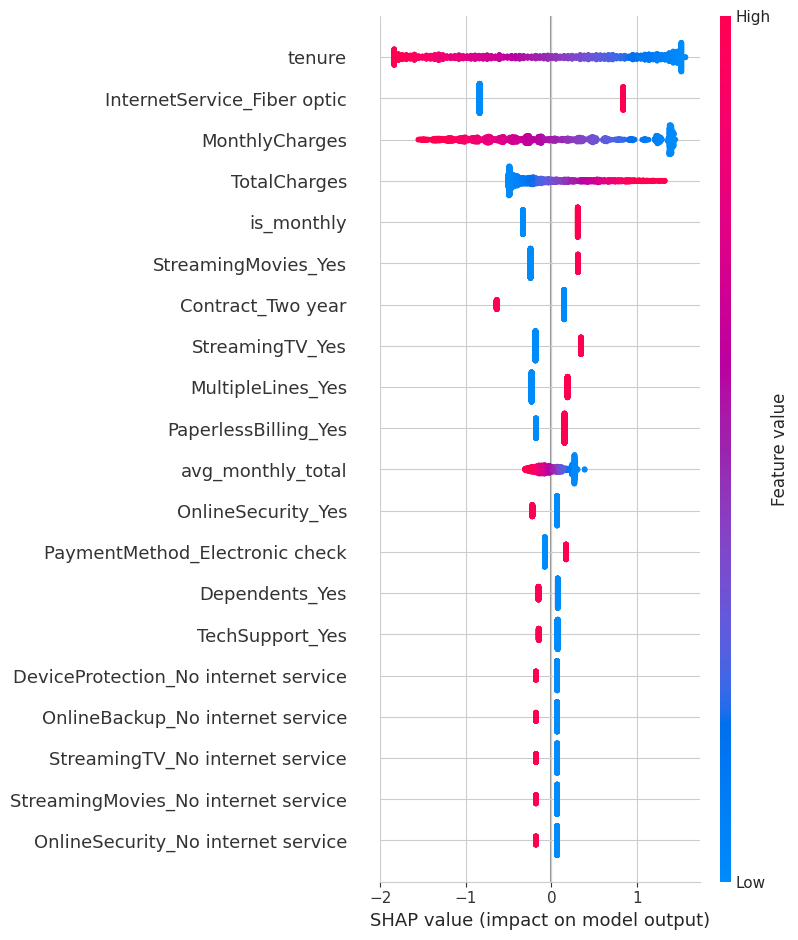

In [40]:
# Import shap
import shap

# LinearExplainer for logistic regression; uses the SCALED training data
explainer = shap.LinearExplainer(logreg, X_train_s)
shap_values = explainer.shap_values(X_test_s)
shap.summary_plot(shap_values, X_test_s, feature_names=list(X.columns))

In [41]:
# Save model, scaled and columns data
import joblib
joblib.dump(logreg, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'columns.pkl')

from google.colab import files
files.download('model.pkl')
files.download('scaler.pkl')
files.download('columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>